In [19]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, random_split
import matplotlib.pyplot as plt


In [20]:

# --- [하이퍼파라미터 설정] ---

HIDDEN_NODES = 128
LR = 0.01
BATCH_SIZE = 100
EPOCHS = 20
ACTIVATION = 'sigmoid'


In [21]:

# --- [데이터 준비] ---
transform = transforms.Compose([transforms.ToTensor()])
full_train = datasets.MNIST(root='./data', train=True, download=True, transform=transform)
test_dataset = datasets.MNIST(root='./data', train=False, download=True, transform=transform)


In [22]:

# Train(5만) / Validation(1만) 분리
train_dataset, val_dataset = random_split(full_train, [50000, 10000])

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)


In [23]:

# --- [모델 설계] ---
class MNIST_Net(nn.Module):
    def __init__(self, hidden_size, act_type):
        super(MNIST_Net, self).__init__()
        self.fc1 = nn.Linear(784, hidden_size) # 입력층 784 -> 은닉층
        self.fc2 = nn.Linear(hidden_size, 10)  # 은닉층 -> 출력층 10
        self.activation = nn.ReLU() if act_type == 'relu' else nn.Sigmoid()

    def forward(self, x):
        x= x.view(-1,784)
        x = self.activation(self.fc1(x))
        return self.fc2(x) # CrossEntropyLoss가 Softmax를 포함함

model = MNIST_Net(HIDDEN_NODES, ACTIVATION)
criterion = nn.CrossEntropyLoss() # 손실함수 crossentropyloss
optimizer = optim.SGD(model.parameters(), lr=LR) # 옵티마이저 sgd


In [24]:

# 기록용 리스트
train_losses = []
val_accuracies = []
train_accuracies = []


# --- [학습 루프] ---
for epoch in range(EPOCHS):
    model.train()
    total_loss = 0
    train_acc =0
    for images, labels in train_loader:
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
        _,predicted=torch.max(outputs.data,1)
        train_acc += (predicted == labels).sum().item()

    avg_loss = total_loss / len(train_loader)
    train_losses.append(avg_loss)
    avg_train_acc=100*train_acc/len(train_dataset)
    train_accuracies.append(avg_train_acc)
    # Validation
    model.eval()
    correct = 0
    with torch.no_grad():
        for images, labels in val_loader:
            outputs = model(images)
            _, predicted = torch.max(outputs.data, 1)
            correct += (predicted == labels).sum().item()

    val_acc = 100 * correct / len(val_dataset)
    val_accuracies.append(val_acc)


    print(f"Epoch [{epoch+1}/{EPOCHS}] Loss: {avg_loss:.4f}, Train Acc: {avg_train_acc:.2f}%, Val Acc: {val_acc:.2f}%")



Epoch [1/20] Loss: 2.2344, Train Acc: 32.89%, Val Acc: 45.71%
Epoch [2/20] Loss: 2.0427, Train Acc: 60.38%, Val Acc: 63.35%
Epoch [3/20] Loss: 1.7352, Train Acc: 68.89%, Val Acc: 70.58%
Epoch [4/20] Loss: 1.3940, Train Acc: 74.13%, Val Acc: 76.11%
Epoch [5/20] Loss: 1.1288, Train Acc: 78.08%, Val Acc: 79.25%
Epoch [6/20] Loss: 0.9479, Train Acc: 80.73%, Val Acc: 81.74%
Epoch [7/20] Loss: 0.8238, Train Acc: 82.44%, Val Acc: 82.88%
Epoch [8/20] Loss: 0.7351, Train Acc: 83.77%, Val Acc: 83.88%
Epoch [9/20] Loss: 0.6695, Train Acc: 84.73%, Val Acc: 84.83%
Epoch [10/20] Loss: 0.6189, Train Acc: 85.53%, Val Acc: 85.48%
Epoch [11/20] Loss: 0.5788, Train Acc: 86.24%, Val Acc: 85.93%
Epoch [12/20] Loss: 0.5462, Train Acc: 86.68%, Val Acc: 86.48%
Epoch [13/20] Loss: 0.5193, Train Acc: 87.23%, Val Acc: 86.77%
Epoch [14/20] Loss: 0.4967, Train Acc: 87.65%, Val Acc: 87.05%
Epoch [15/20] Loss: 0.4775, Train Acc: 88.02%, Val Acc: 87.18%
Epoch [16/20] Loss: 0.4611, Train Acc: 88.26%, Val Acc: 87.51%
E

In [25]:
# --- [최종 Test Accuracy] ---
model.eval()
correct = 0
with torch.no_grad():
    for images, labels in test_loader:
        outputs = model(images)
        _, predicted = torch.max(outputs.data, 1)
        correct += (predicted == labels).sum().item()
print(f"\n최종 Test Accuracy: {100 * correct / len(test_dataset):.2f}%")


최종 Test Accuracy: 89.51%


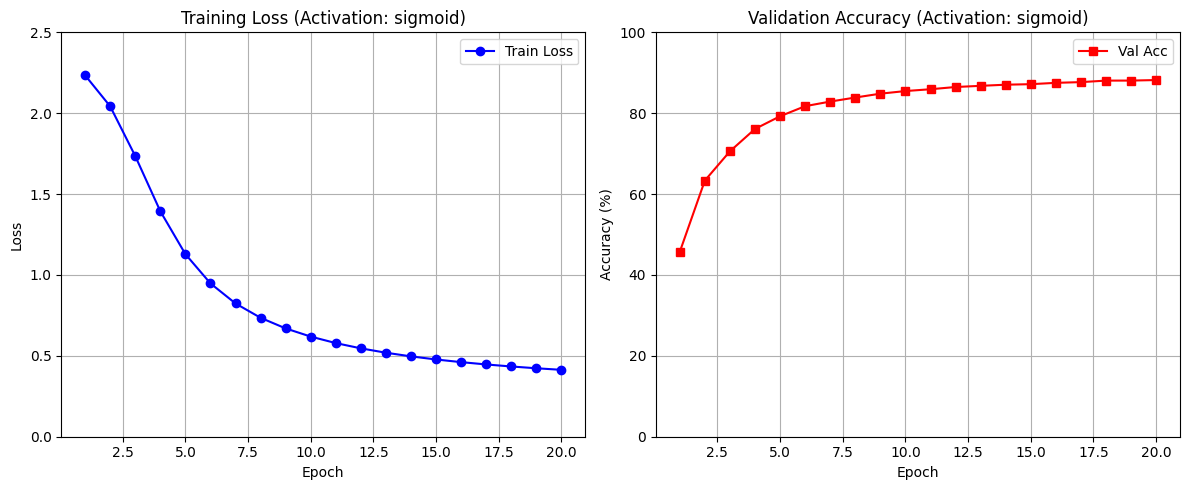

In [26]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 5))

# --- 왼쪽: Training Loss (스케일 0 ~ 2.5 고정!) ---
plt.subplot(1, 2, 1)
plt.plot(range(1, EPOCHS + 1), train_losses, marker='o', color='blue', label='Train Loss')
plt.title(f'Training Loss (Activation: sigmoid)')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.ylim(0, 2.5)
plt.grid(True)
plt.legend()

# --- 오른쪽: Validation Accuracy (스케일 0 ~ 100 고정) ---
plt.subplot(1, 2, 2)
plt.plot(range(1, EPOCHS + 1), val_accuracies, marker='s', color='red', label='Val Acc')
plt.title(f'Validation Accuracy (Activation: sigmoid)')
plt.xlabel('Epoch')
plt.ylabel('Accuracy (%)')
plt.ylim(0, 100)
plt.grid(True)
plt.legend()

plt.tight_layout()
plt.show()